group by year, plot trend lines (rolling average and CI later), export figures 

In [6]:
# load results 

import pandas as pd
import matplotlib.pyplot as plt

metrics_df = pd.read_csv("/Users/mariaworkman/fashion/fashion-neutrality/data/results/metrics_full_run.csv")

# keep only valid rows
metrics_df = metrics_df[metrics_df["ok"] == True]

In [7]:
# aggregate by year 

yearly = (
    metrics_df
    .groupby("year")
    .agg(
        mean_chroma=("mean_chroma", "mean"),
        neutral_share=("neutral_share", "mean"),
        count=("mean_chroma", "size")
    )
    .reset_index()
    .sort_values("year")
)

yearly.head()


,year,mean_chroma,neutral_share,count
0,2000,16.708127,0.699339,100
1,2001,16.130038,0.702347,100
2,2002,14.751548,0.741918,100
3,2003,14.293826,0.747077,100
4,2004,14.250137,0.774431,100


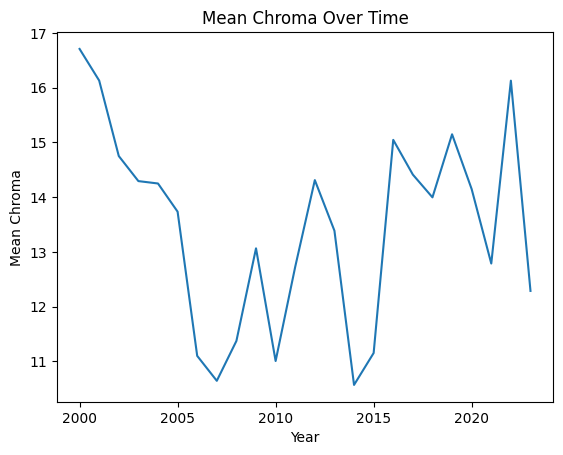

In [8]:
# plot mean chroma over years 

plt.figure()
plt.plot(yearly["year"], yearly["mean_chroma"])
plt.xlabel("Year")
plt.ylabel("Mean Chroma")
plt.title("Mean Chroma Over Time")
plt.show()


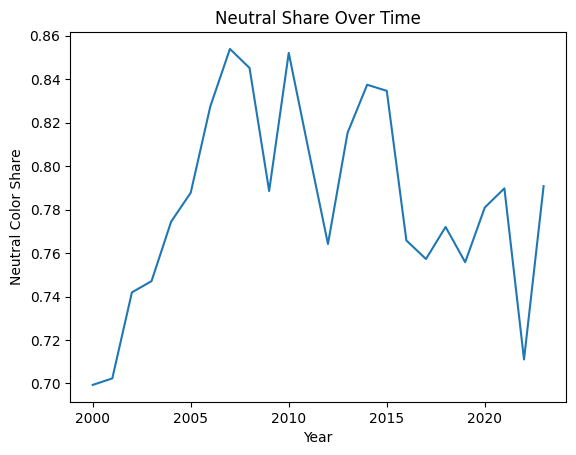

In [9]:
# plot neutral share over years (could be pretty messy, need to adjust cutoff for neutrality)

plt.figure()
plt.plot(yearly["year"], yearly["neutral_share"])
plt.xlabel("Year")
plt.ylabel("Neutral Color Share")
plt.title("Neutral Share Over Time")
plt.show()


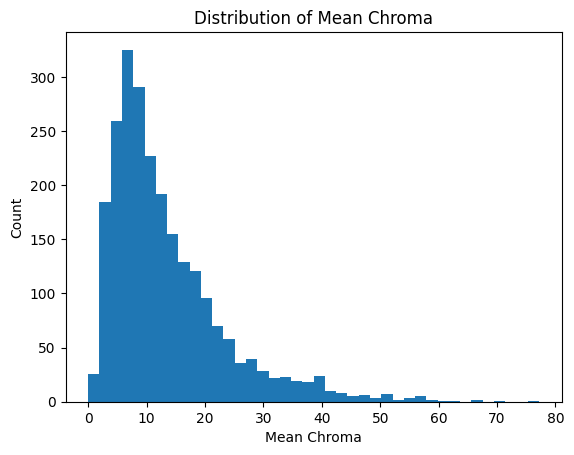

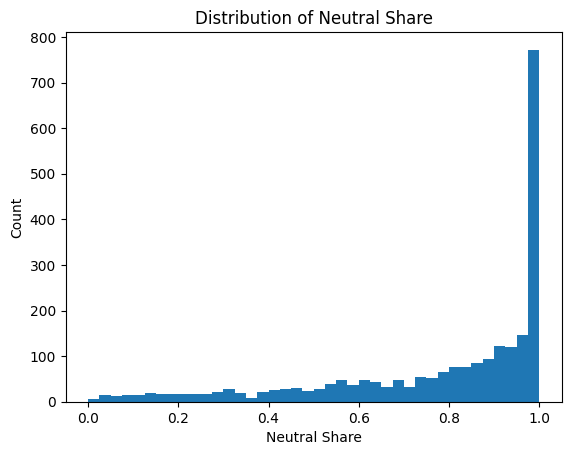

In [10]:
# distribution checks 

plt.figure()
plt.hist(metrics_df["mean_chroma"], bins=40)
plt.xlabel("Mean Chroma")
plt.ylabel("Count")
plt.title("Distribution of Mean Chroma")
plt.show()

plt.figure()
plt.hist(metrics_df["neutral_share"], bins=40)
plt.xlabel("Neutral Share")
plt.ylabel("Count")
plt.title("Distribution of Neutral Share")
plt.show()


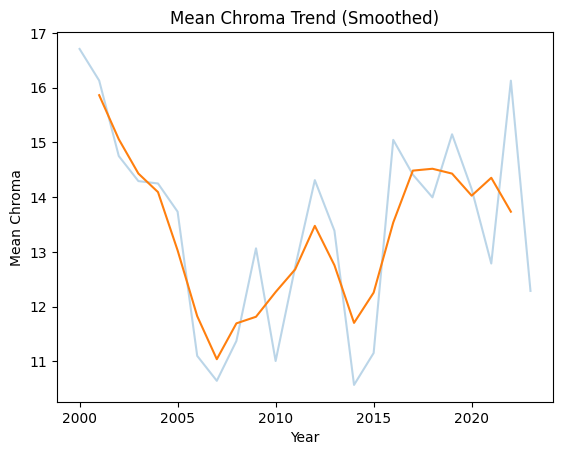

In [11]:
# smooth trend / rolling average to look cool 

yearly["chroma_smooth"] = yearly["mean_chroma"].rolling(3, center=True).mean()
yearly["neutral_smooth"] = yearly["neutral_share"].rolling(3, center=True).mean()

plt.figure()
plt.plot(yearly["year"], yearly["mean_chroma"], alpha=0.3)
plt.plot(yearly["year"], yearly["chroma_smooth"])
plt.xlabel("Year")
plt.ylabel("Mean Chroma")
plt.title("Mean Chroma Trend (Smoothed)")
plt.show()


1. Adding presidential variable.

In [14]:
def get_party(year):
    if 2001 <= year <= 2008:
        return 1  # Republican
    elif 2009 <= year <= 2016:
        return 0  # Democrat
    elif 2017 <= year <= 2020:
        return 1
    elif 2021 <= year <= 2023:
        return 0
    else:
        return None

yearly["rep_pres"] = yearly["year"].apply(get_party)

In [18]:
unemp = pd.read_csv("https://fred.stlouisfed.org/graph/fredgraph.csv?id=UNRATE")

print(unemp.columns)  # always do this first

# adjust column name based on output
date_col = "DATE" if "DATE" in unemp.columns else "observation_date"

unemp["year"] = pd.to_datetime(unemp[date_col]).dt.year

yearly_unemp = (
    unemp
    .groupby("year")
    .agg(unemployment_rate=("UNRATE", "mean"))
    .reset_index()
)

Index(['observation_date', 'UNRATE'], dtype='str')


In [19]:
merged = yearly.merge(yearly_unemp, on="year", how="left")

merged = merged.dropna()

In [20]:
import statsmodels.api as sm

X = merged[["rep_pres", "unemployment_rate", "year"]]
X = sm.add_constant(X)

y = merged["mean_chroma"]

model = sm.OLS(y, X).fit()

print(model.summary())

ModuleNotFoundError: No module named 'statsmodels'